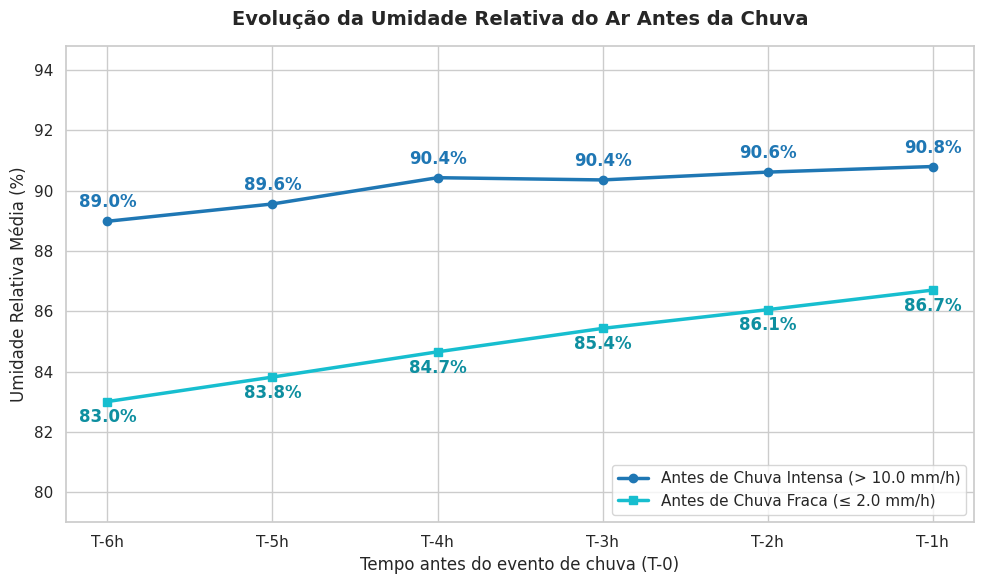

Análise comparativa baseada em 54 eventos de chuva intensa e 1751 de chuva fraca:
Chuva Intensa (Azul): A umidade passa de 89.0% para 90.8%. Variando +1.8%. 
Chuva Fraca (Ciano): A umidade passa de 83.0% para 86.7%. Variando +3.7%.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- DEFINIÇÃO DAS VARIÁVEIS E CARREGAMENTO DOS DADOS ---
# Carregar os dados
df = pd.read_csv("/dados/df_recife.csv", sep=",", encoding="utf-8")

# Limpar nomes das colunas e remover índices extras se existirem
df.columns = df.columns.str.strip()
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Definir o nome da coluna de precipitação e garantir que seja numérica
col_precipitacao = "PRECIPITAÇÃO TOTAL, HORÁRIO (mm)"
df[col_precipitacao] = pd.to_numeric(df[col_precipitacao].astype(str).str.replace(",", "."), errors="coerce")

# Definir a coluna de umidade e garantir que seja numérica
umidade_col = "UMIDADE RELATIVA DO AR, HORARIA (%)"
df[umidade_col] = pd.to_numeric(df[umidade_col].astype(str).str.replace(",", "."), errors="coerce")

# --- ANÁLISE EXPLORATÓRIA ---

# 1. Definir os limiares e identificar os eventos de chuva
chuva_intensa_limiar = 10.0
# Chuva Fraca: entre 0.1 mm/h e 2.0 mm/h
eventos_chuva_intensa = df[df[col_precipitacao] > chuva_intensa_limiar].index
eventos_chuva_fraca = df[(df[col_precipitacao] > 0.1) & (df[col_precipitacao] <= 2.0)].index

# 2. Função para coletar a umidade nas 6 horas anteriores (de T-6h até T-1h)
def extrair_perfis_umidade(indices_eventos):
    perfis = []
    for idx in indices_eventos:
        if idx >= 6:
            historico_umidade = df.loc[idx-6 : idx-1, umidade_col].values
            if not np.isnan(historico_umidade).any():
                perfis.append(historico_umidade)
    return pd.DataFrame(perfis, columns=['T-6h', 'T-5h', 'T-4h', 'T-3h', 'T-2h', 'T-1h'])

perfis_intensa = extrair_perfis_umidade(eventos_chuva_intensa)
perfis_fraca = extrair_perfis_umidade(eventos_chuva_fraca)

# Calcular médias
media_intensa = perfis_intensa.mean()
media_fraca = perfis_fraca.mean()

# Definição de cores
cor_intensa = '#1f77b4'
cor_fraca = '#17becf'

# 3. Plotagem do Gráfico Comparativo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Plotar curva para chuva intensa (Azul)
plt.plot(media_intensa.index, media_intensa.values, marker='o', linewidth=2.5, color=cor_intensa, label=f'Antes de Chuva Intensa (> {chuva_intensa_limiar} mm/h)')
# Plotar curva para chuva fraca (Ciano)
plt.plot(media_fraca.index, media_fraca.values, marker='s', linewidth=2.5, color=cor_fraca, label='Antes de Chuva Fraca (≤ 2.0 mm/h)')

# Adicionar anotações de valores
for i, txt in enumerate(media_intensa.values):
    plt.annotate(f"{txt:.1f}%", (media_intensa.index[i], media_intensa.values[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontweight='bold', color=cor_intensa)

for i, txt in enumerate(media_fraca.values):
    plt.annotate(f"{txt:.1f}%", (media_fraca.index[i], media_fraca.values[i]),
                 textcoords="offset points", xytext=(0,-15), ha='center', fontweight='bold', color='#0e8fa0')

plt.title("Evolução da Umidade Relativa do Ar Antes da Chuva", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Tempo antes do evento de chuva (T-0)", fontsize=12)
plt.ylabel("Umidade Relativa Média (%)", fontsize=12)
plt.ylim(min(min(media_intensa.values), min(media_fraca.values)) - 4, max(max(media_intensa.values), max(media_fraca.values)) + 4)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

print(f"Análise comparativa baseada em {len(perfis_intensa)} eventos de chuva intensa e {len(perfis_fraca)} de chuva fraca:")
print(f"Chuva Intensa (Azul): A umidade passa de {media_intensa['T-6h']:.1f}% para {media_intensa['T-1h']:.1f}%. Variando {media_intensa['T-1h'] - media_intensa['T-6h']:+.1f}%. ")
print(f"Chuva Fraca (Ciano): A umidade passa de {media_fraca['T-6h']:.1f}% para {media_fraca['T-1h']:.1f}%. Variando {media_fraca['T-1h'] - media_fraca['T-6h']:+.1f}%.")